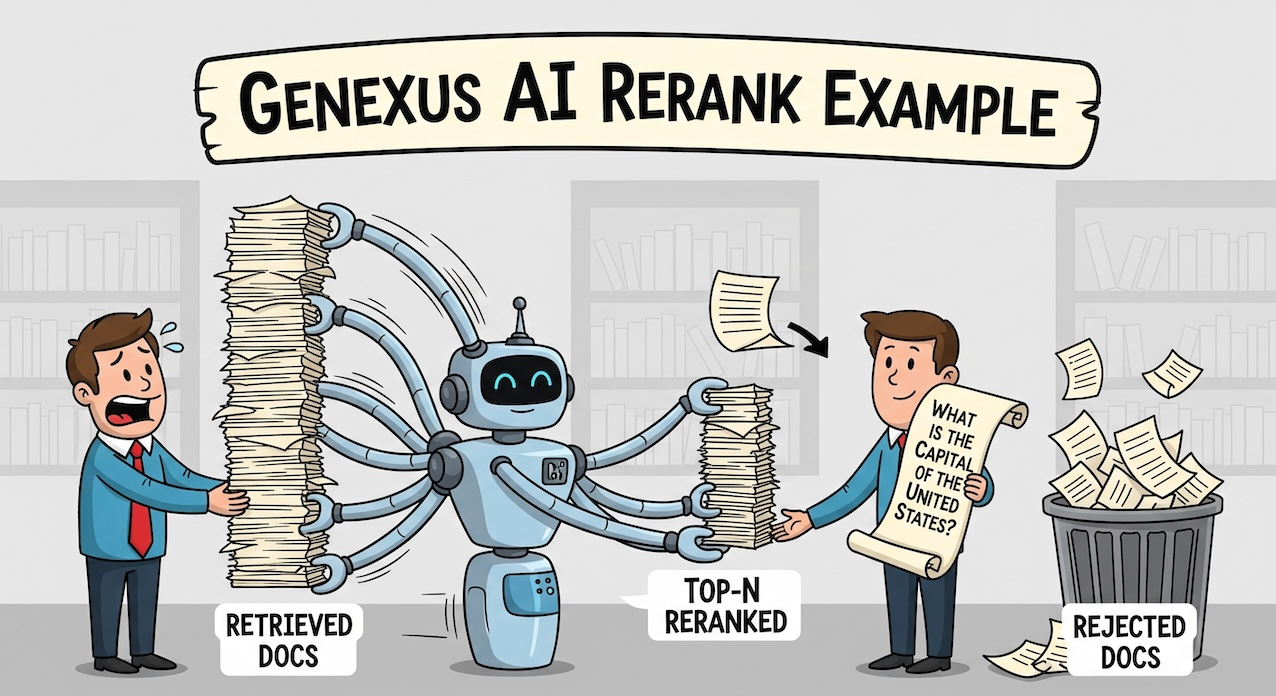

# Genexus AI Rerank Example

This notebook demonstrates how to use the Genexus AI Rerank API to reorder a list of documents based on their relevance to a given query.

## Setup

1. Obtain your `GENEXUS_URL` and `SAIA_PROJECT_APITOKEN` from your Genexus AI project settings.
2. Store these values securely in Colab's Secrets Manager with the names `GENEXUS_URL` and `SAIA_PROJECT_APITOKEN`.

## Usage

The notebook performs the following steps:

1. **Define Documents and Query**: A list of documents in multiple languages and a query are defined.
2. **Prepare Payload**: A JSON payload is created with the model, query, documents, and the desired number of top results (`top_n`).
3. **Call the Rerank API**: A POST request is sent to the Genexus AI Rerank API endpoint with the prepared payload and authorization headers.
4. **Process Results**: The JSON response from the API is parsed, and the top documents based on their relevance score are displayed. A threshold is applied to filter results by relevance.

## Code

The notebook contains the following key code cells:

- Loading credentials from Colab secrets.
- Defining the documents and query.
- Preparing the API request payload.
- Making the API call using `curl` (demonstration) and `requests` library.
- Parsing and displaying the reranked documents with their relevance scores.

## Results

The output shows the documents reordered by their relevance to the query "What is the Capital of the United States?", with the most relevant documents listed first, along with their scores. A threshold is applied to show only results above a certain relevance score.

[RE-RANK DOC](https://wiki.genexus.com/enterprise-ai/wiki?625,Rerank+API)

In [ ]:
from google.colab import userdata
BASE_URL = userdata.get('GENEXUS_URL')
SAIA_PROJECT_APITOKEN = userdata.get('GENEXUS_KEY')

In [ ]:
import json
documents = [
        "Carson City is the capital city of the American state of Nevada.",
        "The Commonwealth of the Northern Mariana Islands is a group of islands in the Pacific Ocean. Its capital is Saipan.",
        "Washington, D.C. is the capital of the United States.",
        "Capital punishment has existed in the United States since before it was a country.",
        "Carson City es la capital del estado estadounidense de Nevada.",
        "La Mancomunidad de las Islas Marianas del Norte es un grupo de islas en el Océano Pacífico. Su capital es Saipán.",
        "Washington D. C. es la capital de los Estados Unidos.",
        "La pena capital ha existido en los Estados Unidos desde antes de que fuera un país.",
        "卡森城是美国内华达州的首府。",
        "北马里亚纳群岛自治邦是太平洋上的一组岛屿。它的首府是塞班岛。",
        "华盛顿特区是美国的首都。",
        "死刑在美国早在成为国家之前就已经存在。"
    ]
query = "What is the Capital of the United States?"
query_payload = {
    "model": "cohere/rerank-v3.5",
    "query": query,
    "documents": documents,
    "top_n": 6
}

# Convert payload to JSON string
data_str = json.dumps(query_payload)

In [ ]:
# Now construct the curl command with interpolated variables
result = !curl --location "{BASE_URL}/rerank" \
  --header "Content-Type: application/json" \
  --header "Authorization: Bearer {SAIA_PROJECT_APITOKEN}" \
  --data-raw '{data_str}'

result[0]

'{"meta":{"billed_units":{"search_units":1},"api_version":{"version":"2"}},"usage":{"total_cost":0.002,"total_tokens":0,"currency":"USD"},"id":"eb7ab044-2fa2-4d41-8201-f2bf32843b0c","results":[{"index":2,"relevance_score":0.8963332},{"index":6,"relevance_score":0.76617163},{"index":10,"relevance_score":0.6768127},{"index":4,"relevance_score":0.23978564},{"index":0,"relevance_score":0.17384885},{"index":7,"relevance_score":0.1619425}]}'

In [ ]:
from rich import print
result_data = json.loads(result[0])
print(result_data)

{
    'meta': {'billed_units': {'search_units': 1}, 'api_version': {'version': '2'}},
    'usage': {'total_cost': 0.002, 'total_tokens': 0, 'currency': 'USD'},
    'id': 'eb7ab044-2fa2-4d41-8201-f2bf32843b0c',
    'results': [
        {'index': 2, 'relevance_score': 0.8963332},
        {'index': 6, 'relevance_score': 0.76617163},
        {'index': 10, 'relevance_score': 0.6768127},
        {'index': 4, 'relevance_score': 0.23978564},
        {'index': 0, 'relevance_score': 0.17384885},
        {'index': 7, 'relevance_score': 0.1619425}
    ]
}

In [ ]:
indexes = [i['index'] for i in result_data['results']]
print([documents[i] for i in indexes])

[
    'Washington, D.C. is the capital of the United States.',
    'Washington D.\u202fC. es la capital de los Estados Unidos.',
    '华盛顿特区是美国的首都。',
    'Carson City es la capital del estado estadounidense de Nevada.',
    'Carson City is the capital city of the American state of Nevada.',
    'La pena capital ha existido en los Estados Unidos desde antes de que fuera un país.'
]

In [ ]:
import requests

# User query
query = "What is the Capital of the United States?"

# Request payload
query_payload = {
    "model": "cohere/rerank-v3.5",  # You can swap this with another supported model
    "query": query,
    "documents": documents,
    "top_n": 6
}
threshold = 0.6

# HTTP headers with authorization
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {SAIA_PROJECT_APITOKEN}"  # Make sure this token is defined
}

print(f"🔍 Query: '{query}'")

try:
    # Send the POST request
    response = requests.post(f"{BASE_URL}/rerank", json=query_payload, headers=headers)
    response.raise_for_status()

    # Parse and display results
    result_data = response.json()
    results = filter(lambda x:x['relevance_score']>threshold, result_data.get("results", []))

    if results:
        print("\n📊 Top results:")
        for rank, item in enumerate(results, start=1):
            doc_index = item["index"]
            score = item.get("relevance_score", "N/A")
            print(f"{rank}. {documents[doc_index]} (Score: {score})")
    else:
        print("⚠️ No results returned by the rerank model.")

except requests.exceptions.RequestException as e:
    print("❌ Request failed:", e)
except Exception as e:
    print("⚠️ Unexpected error:", e)


🔍 Query: 'What is the Capital of the United States?'

📊 Top results:

1. Washington, D.C. is the capital of the United States. (Score: 0.8963332)

2. Washington D. C. es la capital de los Estados Unidos. (Score: 0.76617163)

3. 华盛顿特区是美国的首都。 (Score: 0.6768127)